In [2]:
import pandas as pd

# Lecture du fichier
df_raw = pd.read_excel('Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx', header=None)

# Trouver la colonne FR diesel
header_row = df_raw.iloc[0]
fr_diesel_col = header_row[header_row == 'FR_price_with_tax_diesel'].index[0]

# Extraire date + colonne FR diesel (données à partir de la ligne 3)
df = df_raw.iloc[3:, [0, fr_diesel_col]].copy()
df.columns = ['date', 'prix_diesel_france']

# Nettoyage
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['prix_diesel_france'] = pd.to_numeric(df['prix_diesel_france'], errors='coerce')
df = df.dropna().sort_values('date').reset_index(drop=True)

# Conversion €/1000L → €/L
df['prix_diesel_france_eur_L'] = df['prix_diesel_france'] / 1000

# Filtre 2007-2026
df = df[(df['date'].dt.year >= 2007) & (df['date'].dt.year <= 2026)]

df[['date', 'prix_diesel_france_eur_L']].to_csv('prix_diesel_france.csv', index=False)

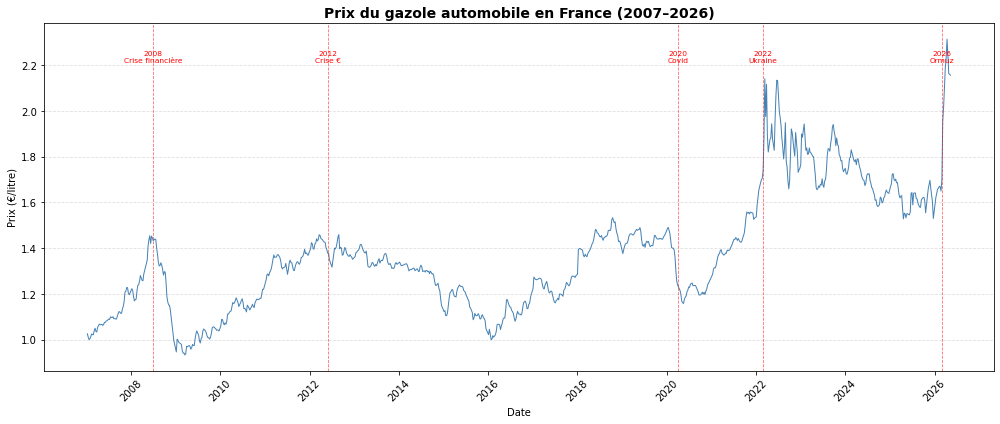

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Chargement
df = pd.read_csv('prix_diesel_france.csv', parse_dates=['date'])

# Graphique
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['date'], df['prix_diesel_france_eur_L'], color='steelblue', linewidth=1)

# Annotations des événements clés
evenements = {
    '2008\nCrise financière': '2008-07-01',
    '2012\nCrise €': '2012-06-01',
    '2020\nCovid': '2020-04-01',
    '2022\nUkraine': '2022-03-01',
    '2026\nOrmuz': '2026-03-01',
}

for label, date in evenements.items():
    ax.axvline(pd.to_datetime(date), color='red', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(pd.to_datetime(date), ax.get_ylim()[1] * 0.95, label,
            fontsize=7.5, color='red', ha='center', va='top')

# Mise en forme
ax.set_title('Prix du gazole automobile en France (2007–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix (€/litre)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

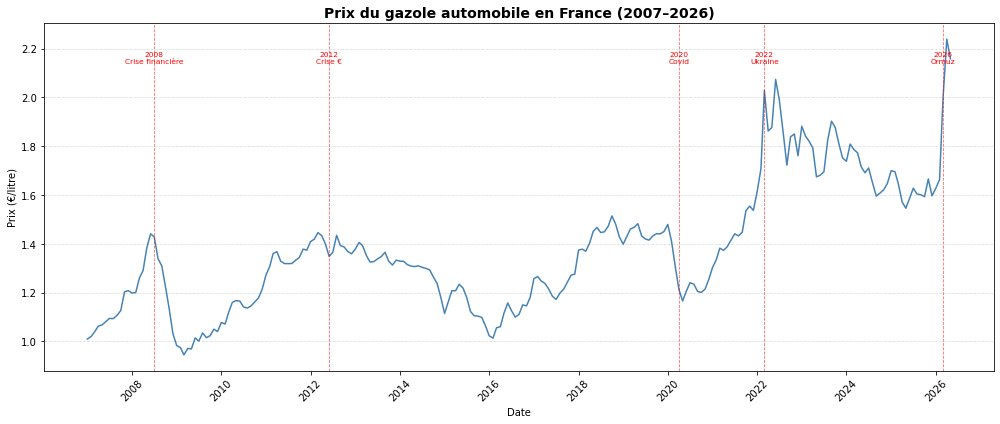

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Chargement
df = pd.read_csv('prix_diesel_france.csv', parse_dates=['date'])

# Moyenne mensuelle
df['mois'] = df['date'].dt.to_period('M')
df_mensuel = df.groupby('mois')['prix_diesel_france_eur_L'].mean().reset_index()
df_mensuel['date'] = df_mensuel['mois'].dt.to_timestamp()

# Graphique
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_mensuel['date'], df_mensuel['prix_diesel_france_eur_L'], color='steelblue', linewidth=1.5)

# Annotations des événements clés
evenements = {
    '2008\nCrise financière': '2008-07-01',
    '2012\nCrise €': '2012-06-01',
    '2020\nCovid': '2020-04-01',
    '2022\nUkraine': '2022-03-01',
    '2026\nOrmuz': '2026-03-01',
}

for label, date in evenements.items():
    ax.axvline(pd.to_datetime(date), color='red', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(pd.to_datetime(date), ax.get_ylim()[1] * 0.95, label,
            fontsize=7.5, color='red', ha='center', va='top')

# Mise en forme
ax.set_title('Prix du gazole automobile en France (2007–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix (€/litre)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()